## Лабораторная работа №1 | Вариант 5

Выполнил: 

### 1. Numpy

In [2]:
import numpy as np

1. Создайте единичную матрицу размером 3х3

In [3]:
ematrix = np.eye(3)

2. Создайте кастомный dtype который описывает цвет состоящий из 4х unsigned bytes(RGBA пиксель)

In [4]:
rgba = np.dtype([('r', np.uint8), ('g', np.uint8), ('b', np.uint8), ('a', np.uint8)])

3. Как игнорировать все numpy warnings(не рекомендуем к использованию)?

In [5]:
np.seterr(all='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

4. Создайте случайный вектор размера 10 и отсортируйте его

In [6]:
randomVector = np.random.rand(10)
sortedVector = np.sort(randomVector)

5. Создайте read-only массив(неизменяемый)

In [7]:

mas = np.array([2, 3, 4])
mas.flags.writeable = False

6. Рассмотрим случайную матрицу размером 10х2, представляющую декартовы координаты, преобразуем их в полярные координаты

In [8]:
decartCoords = np.random.rand(10, 2)
x, y = decartCoords[:, 0], decartCoords[:, 1]
r = np.hypot(x, y)
theta = np.arctan2(y, x)
polarCoords = np.column_stack((r, theta))
print(decartCoords)
print(polarCoords)

[[0.28863365 0.33836009]
 [0.54749432 0.17486744]
 [0.24101572 0.8025252 ]
 [0.87141671 0.54921225]
 [0.99897601 0.17756784]
 [0.55738274 0.54802991]
 [0.2873758  0.29985469]
 [0.02465593 0.02630988]
 [0.6510951  0.74197169]
 [0.09996688 0.30452396]]
[[0.44474367 0.86454182]
 [0.57474224 0.30915486]
 [0.83793513 1.27904443]
 [1.03004911 0.56236723]
 [1.01463462 0.17591256]
 [0.78167276 0.77693742]
 [0.41532841 0.80664539]
 [0.03605725 0.81783891]
 [0.98714073 0.85054078]
 [0.32051243 1.2536073 ]]


7. Создайте структурированный массив с координатами x и y, охватывающий область [0,1]x[0,1]

In [33]:
coordDtype = np.dtype([('x', 'f8'), ('y', 'f8')])
xCoords = np.linspace(0, 1, 5)
yCoords = np.linspace(0, 1, 5)
xx, yy = np.meshgrid(xCoords, yCoords)
coordinates = np.zeros(xx.size, dtype=coordDtype)
coordinates['x'] = xx.flatten()
coordinates['y'] = yy.flatten()
print(coordinates)
print(f"Размер массива: {coordinates.size}")
print(f"Форма массива: {coordinates.shape}")
print(f"dtype: {coordinates.dtype}")

[(0.  , 0.  ) (0.25, 0.  ) (0.5 , 0.  ) (0.75, 0.  ) (1.  , 0.  )
 (0.  , 0.25) (0.25, 0.25) (0.5 , 0.25) (0.75, 0.25) (1.  , 0.25)
 (0.  , 0.5 ) (0.25, 0.5 ) (0.5 , 0.5 ) (0.75, 0.5 ) (1.  , 0.5 )
 (0.  , 0.75) (0.25, 0.75) (0.5 , 0.75) (0.75, 0.75) (1.  , 0.75)
 (0.  , 1.  ) (0.25, 1.  ) (0.5 , 1.  ) (0.75, 1.  ) (1.  , 1.  )]
Размер массива: 25
Форма массива: (25,)
dtype: [('x', '<f8'), ('y', '<f8')]


8. Учитывая два массива X и Y, постройте матрицу Коши $C$ ($C_{ij} =\frac{1}{x_i - y_j}$)

In [35]:
x = np.random.normal(size=(5))
y = np.random.normal(size=(5))
print(x)
print(y)
C = 1 / np.subtract.outer(x, y)
print(C)

[ 0.70932747  0.15273533 -1.03614535 -0.99246473 -1.91612641]
[-1.53161059 -0.00698256 -1.92047386  0.06776647  0.24368761]
[[  0.44624169   1.39604355   0.38025686   1.55869822   2.14758246]
 [  0.59370227   6.26103962   0.48234399  11.76901802 -10.99477575]
 [  2.01830504  -0.97166358   1.13080149  -0.90586946  -0.78135196]
 [  1.85478563  -1.0147317    1.0775756   -0.9431905   -0.80896178]
 [ -2.60067323  -0.523795   230.01993735  -0.50405947  -0.46300283]]


9. Как конвертировать массив float(32 bit) к массиву целых чисел (integer 32 bit) in place?

In [36]:
arr = np.array([10.5, 20.7, 30.2, 40.9], dtype=np.float32)
arr = arr.astype(np.int32, copy=False)

10. Как случайно заменить p элементов в 2D массиве?

In [37]:
arr = np.arange(25).reshape(5, 5)
print("Исходный массив:")
print(arr)
p = 8
replacementValue = -1
def ReplaceRandomElements(arr, p, replacementValue):
    result = arr.copy()
    ind = np.random.choice(arr.size, size=p, replace=False)
    indices2d = np.unravel_index(ind, arr.shape)
    result[indices2d] = replacementValue
    return result

modifiedArr = ReplaceRandomElements(arr, p, replacementValue)
print(f"\nПосле замены {p} случайных элементов на {replacementValue}:")
print(modifiedArr)

Исходный массив:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

После замены 8 случайных элементов на -1:
[[ 0 -1  2 -1  4]
 [ 5 -1 -1  8  9]
 [-1 -1 12 13 14]
 [15 16 -1 18 19]
 [20 21 22 23 -1]]


### 2. Pandas

Найдите ответы на вопросы или выполните действия с предложенным датасетом 

Классический начальный набор данных - данные пассажиров титаника.

Файл: `data.csv`

```
PassangerId - уникальный номер пассажира
Survived - выжил человек или нет
Pclass - класс обслуживания
Name - имя человека, обращение к ней/нему
Sex - пол человека
Age - возраст на момент крушения
SibSp - количество братьев и сестер / супругов на борту "Титаника"
Parch - количество родителей / детей на борту "Титаника"
Ticket - номер билета
Fare - стоимость проезда для пассажиров
Cabin - каюта
Embarked - причал отбытия. C = Cherbourg Q = Queenstown S = Southampton
```

In [13]:
import pandas as pd

In [14]:
df = pd.read_csv('data.csv')

1. Узнайте сколько было на борту человек

In [38]:
totalPeople = len(df)
print(f"Всего людей {totalPeople}")

Всего людей 891


2. Какой медианный и средний возраста пассажиров

In [39]:
meanAge = df['Age'].mean()
medianAge = df['Age'].median()

print(f"Средний возраст {meanAge:.2f} лет")
print(f"Медианный возраст {medianAge:.2f} лет")

Средний возраст 29.70 лет
Медианный возраст 28.00 лет


3. Посчитайте процент выживаемости детей(до 16 лет) и взрослых

In [ ]:
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x < 16 else 'Adult')
survival = df.groupby('AgeGroup')['Survived'].mean() * 100
print("Процент выживаемости")
print(f"Дети {survival['Child']:.1f}%")
print(f"Взрослые {survival['Adult']:.1f}%")

Процент выживаемости
Дети 59.0%
Взрослые 36.3%
Разница 22.8%


4. Верна ли гипотеза, что женщины и дети сажались в шлюпки первыми и выживали больше?

In [ ]:
df['Category'] = 'Adult Male'
df.loc[df['Sex'] == 'female', 'Category'] = 'Woman'
df.loc[df['Age'] < 16, 'Category'] = 'Child'
survivalByCategory = df.groupby('Category')['Survived'].agg(['count', 'sum', 'mean']).round(3)
survivalByCategory.columns = ['Total', 'Survived', 'SurvivalRate']
survivalByCategory['SurvivalPercent'] = (survivalByCategory['SurvivalRate'] * 100).round(1)
print("Выживаемость по категориям")
print(survivalByCategory)

Выживаемость по категориям:
            Total  Survived  SurvivalRate  SurvivalPercent
Category                                                  
Adult Male    537        88         0.164             16.4
Child          83        49         0.590             59.0
Woman         271       205         0.756             75.6


5. Зависит ли выживаемость от класса обслуживания?

In [41]:
survivalByClass = df.groupby('Pclass')['Survived'].mean() * 100
print("Выживаемость по классам обслуживания")
for pclass in [1, 2, 3]:
    print(f"Класс {pclass}: {survivalByClass[pclass]:.1f}%")

Выживаемость по классам обслуживания
Класс 1: 63.0%
Класс 2: 47.3%
Класс 3: 24.2%


6. Посчитайте средний возраст умерших женщин и мужчин

In [42]:
dead = df[df['Survived'] == 0]
avgAgeDead = dead.groupby('Sex')['Age'].mean()
print("Средний возраст умерших")
print(f"Мужчины {avgAgeDead['male']:.1f} лет")
print(f"Женщины {avgAgeDead['female']:.1f} лет")

Средний возраст умерших
Мужчины 31.6 лет
Женщины 25.0 лет


7. Различается ли процент выживаемости пассажиров с хотя бы одним родственником на борту и одиночек?

In [43]:
df['HasFamily'] = (df['SibSp'] + df['Parch']) > 0
survivalByFamily = df.groupby('HasFamily')['Survived'].mean() * 100
print("Выживаемость пассажиров с родственниками и одиночек:")
print(f"С родственниками {survivalByFamily[True]:.1f}%")
print(f"Одиночки {survivalByFamily[False]:.1f}%")

Выживаемость пассажиров с родственниками и одиночек:
С родственниками 50.6%
Одиночки 30.4%


8. Различается ли средняя стоимость билета у умерших и выживших пассажиров?

In [ ]:
avgFare = df.groupby('Survived')['Fare'].mean()
print("Средняя стоимость билета:")
print(f"Выжившие: ${avgFare[1]:.2f}")
print(f"Умершие: ${avgFare[0]:.2f}")


Средняя стоимость билета:
Выжившие: $48.40
Умершие: $22.12


9. Выведите максимальный и минимальный возраст выживших пассажиров во 2 классе обслуживания

In [ ]:
survived2ndClass = df[(df['Survived'] == 1) & (df['Pclass'] == 2)]
minAge = survived2ndClass['Age'].min()
maxAge = survived2ndClass['Age'].max()
print("Возраст выживших пассажиров 2 класса")
print(f"Минимальный возраст {minAge:.1f} лет")
print(f"Максимальный возраст {maxAge:.1f} лет")

Возраст выживших пассажиров 2 класса:
Минимальный возраст: 0.7 лет
Максимальный возраст: 62.0 лет


10. Подтвердите или опровергните гипотезу: молодым мужчинам(от 18 лет) выжить легче, чем более взрослым

In [79]:
men18Plus = df[(df['Sex'] == 'male') & (df['Age'] >= 18)].copy()
men18Plus['AgeGroup'] = '30 лет'
men18Plus.loc[men18Plus['Age'] <= 30, 'AgeGroup'] = '18-30 лет'
survivalMen = men18Plus.groupby('AgeGroup')['Survived'].mean() * 100
print("Выживаемость мужчин от 18 лет")
print(f"18-30 лет: {survivalMen['18-30 лет']:.1f}%")
print(f"30+ лет: {survivalMen['30 лет']:.1f}%")

Выживаемость мужчин от 18 лет
18-30 лет: 15.0%
30+ лет: 20.3%


### 3. Визуализация

Используя библиотеки matplotlib/sns/plotly/pandas и набор данных представленный ранее визуализируйте

1. Постройте гистограмму распределения возростов пассажиров

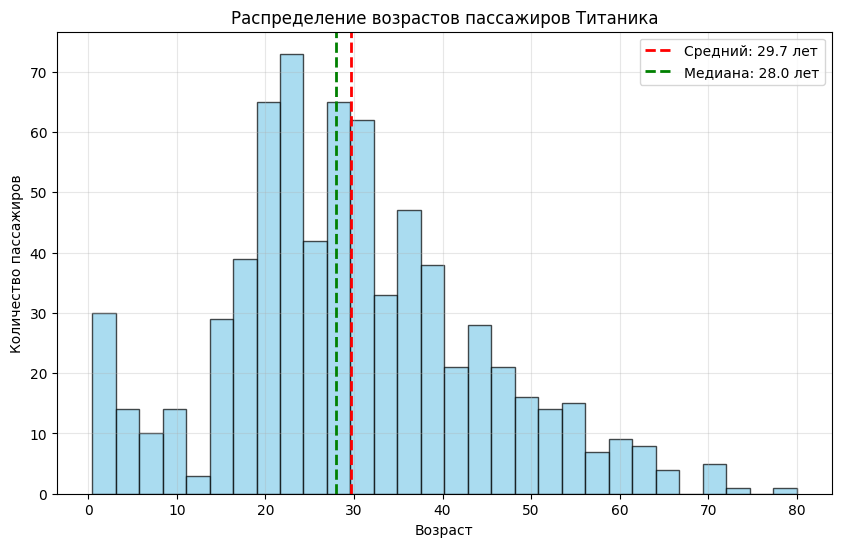

In [80]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.title('Распределение возрастов пассажиров Титаника')
plt.grid(alpha=0.3)
mean_age = df['Age'].mean()
median_age = df['Age'].median()
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Средний: {mean_age:.1f} лет')
plt.axvline(median_age, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_age:.1f} лет')
plt.legend()
plt.show()

2. Постройте гистограммы распределения цен для пассажиров разных классов

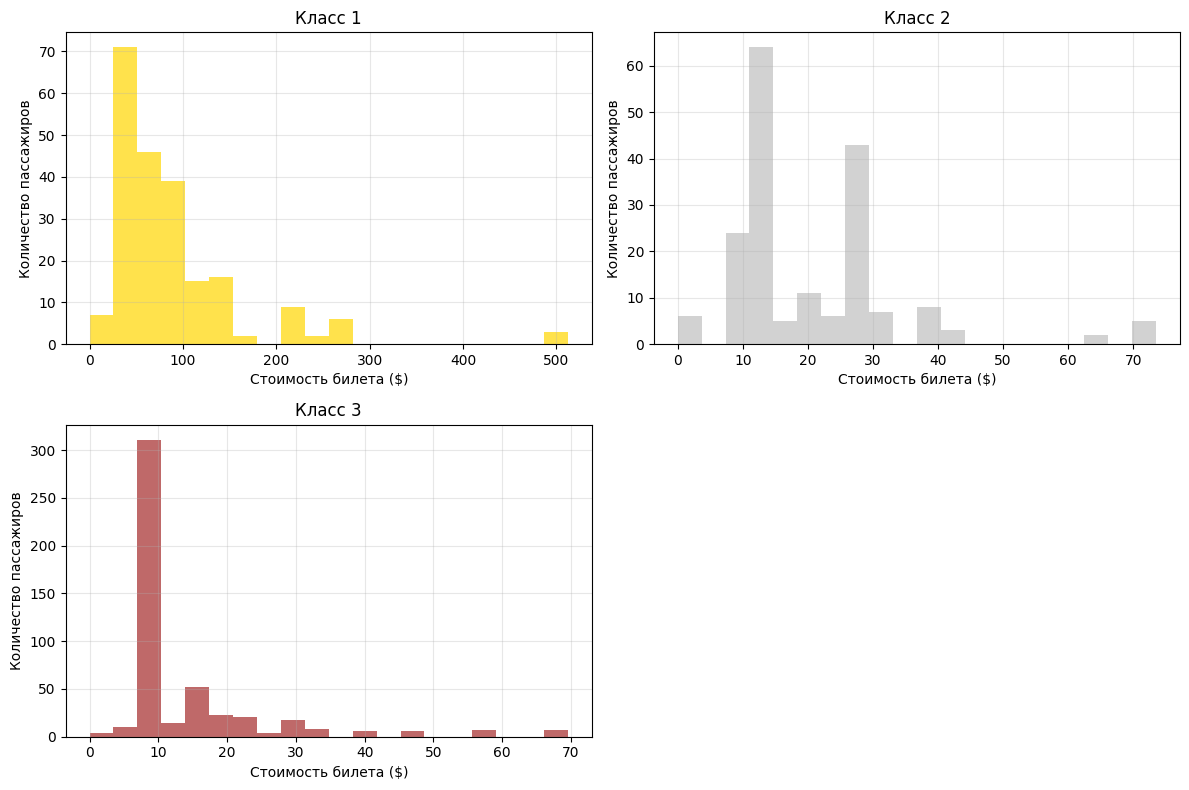

In [ ]:
plt.figure(figsize=(12, 8))
for i, pclass in enumerate([1, 2, 3], 1):
    plt.subplot(2, 2, i)
    class_data = df[df['Pclass'] == pclass]['Fare']
    plt.hist(class_data, bins=20, alpha=0.7, color=['gold', 'silver', 'brown'][i-1])
    plt.title(f'Класс {pclass}')
    plt.xlabel('Стоимость билета ($)')
    plt.ylabel('Количество пассажиров')
    plt.grid(alpha=0.3)
    
plt.tight_layout()
plt.show()

3. Постройте зависимость цены от возраста пассажира

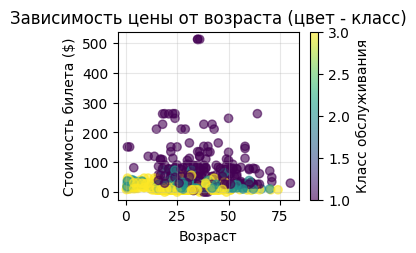

In [82]:
plt.subplot(2, 2, 1)
scatter = plt.scatter(df['Age'], df['Fare'], c=df['Pclass'], alpha=0.6, cmap='viridis')
plt.colorbar(scatter, label='Класс обслуживания')
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета ($)')
plt.title('Зависимость цены от возраста (цвет - класс)')
plt.grid(alpha=0.3)

4. Постройте box plot отображающий распределение цен на билеты в разных классах

C:\Users\zaxar\AppData\Local\Temp\ipykernel_13172\188328947.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(class_data, labels=['1 класс', '2 класс', '3 класс'])


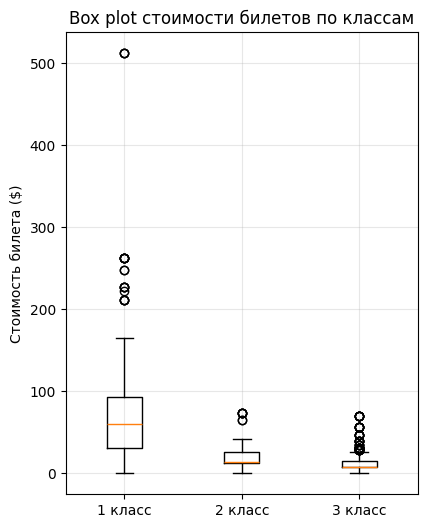

In [ ]:

plt.figure(figsize=(10, 6))

# Способ 1: Box plot с помощью matplotlib
plt.subplot(1, 2, 1)
classData = [df[df['Pclass'] == i]['Fare'] for i in [1, 2, 3]]
plt.boxplot(classData, labels=['1 класс', '2 класс', '3 класс'])
plt.title('Box plot стоимости билетов по классам')
plt.ylabel('Стоимость билета ($)')
plt.grid(alpha=0.3)

5. Визуализируйте распределение долей выживших среди мужчин, женщин и детей(до 16 лет)

Статистика выживаемости по категориям:
          Total  Survived  SurvivalRate
Category                               
Child        83        49          59.0
Female      271       205          75.6
Male        537        88          16.4


(0.0, 100.0)

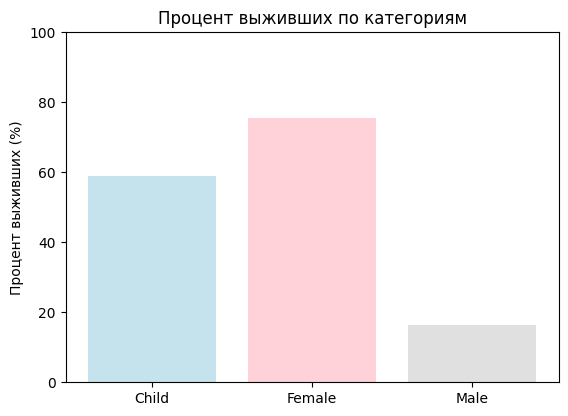

In [ ]:
df['Category'] = 'Male'
df.loc[df['Sex'] == 'female', 'Category'] = 'Female'
df.loc[df['Age'] < 16, 'Category'] = 'Child'
categorySurvival = df.groupby('Category')['Survived'].agg(['count', 'sum']).round(2)
categorySurvival['SurvivalRate'] = (categorySurvival['sum'] / categorySurvival['count'] * 100).round(1)
categorySurvival.columns = ['Total', 'Survived', 'SurvivalRate']
print("Статистика выживаемости по категориям:")
print(categorySurvival)
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
categories = ['Child', 'Female', 'Male']
survivalRates = [categorySurvival.loc[cat, 'SurvivalRate'] for cat in categories]
colors = ['lightblue', 'pink', 'lightgray']
bars = plt.bar(categories, survivalRates, color=colors, alpha=0.7)
plt.title('Процент выживших по категориям')
plt.ylabel('Процент выживших (%)')
plt.ylim(0, 100)

6. Сравните плотности распределения возростов выживших и умерших пассажиров, сделайте выводы

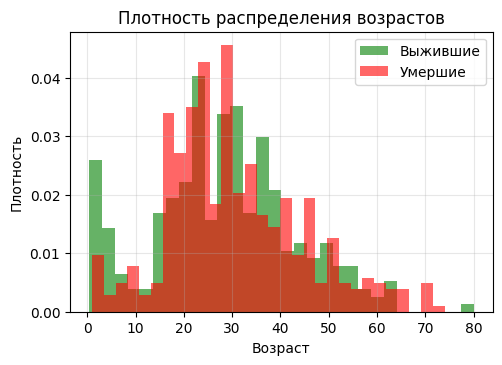

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
survivedAges = df[df['Survived'] == 1]['Age'].dropna()
deadAges = df[df['Survived'] == 0]['Age'].dropna()
plt.hist(survivedAges, bins=30, alpha=0.6, color='green', label='Выжившие', density=True)
plt.hist(deadAges, bins=30, alpha=0.6, color='red', label='Умершие', density=True)
plt.xlabel('Возраст')
plt.ylabel('Плотность')
plt.title('Плотность распределения возрастов')
plt.legend()
plt.grid(alpha=0.3)

7. Постройте круговую диаграмму отображающую выживаемость мужчин и женщин в разных классах обслуживания(визуализация должна быть интуитивно понятная без объяснений, женщины и мужчины соответствующих классов объеденены визуально в одну группу и 2 подгруппы)*

\* Задание на доп. балл

Выживаемость по классам и полу (%)
   Pclass     Sex   Survived
0       1  female  96.808511
1       1    male  36.885246
2       2  female  92.105263
3       2    male  15.740741
4       3  female  50.000000
5       3    male  13.544669


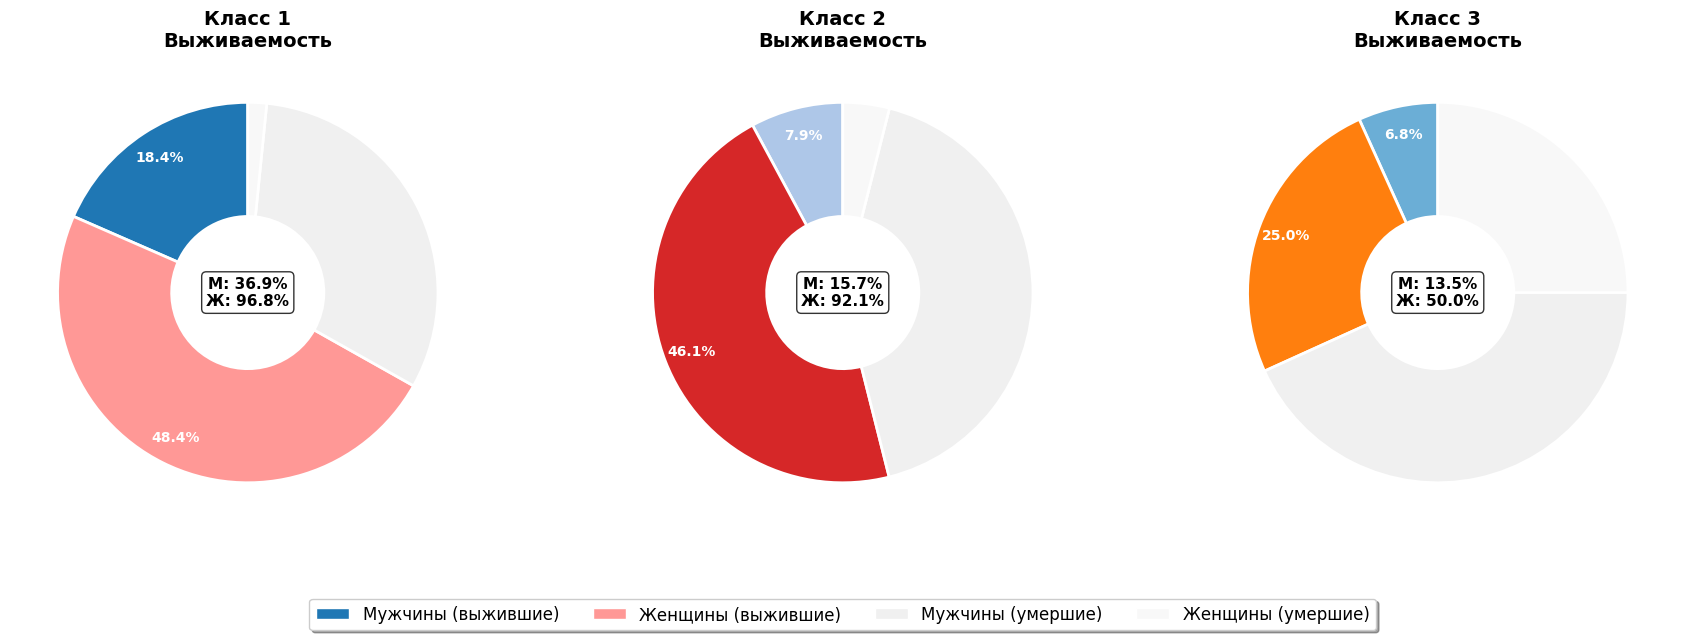

In [83]:
Data = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
Data = Data.reset_index()

print("Выживаемость по классам и полу (%)")
print(Data)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colorsMen = ['#1f77b4', '#aec7e8', '#6baed6']
colorsWomen = ['#ff9896', '#d62728', '#ff7f0e']

for i, pclass in enumerate([1, 2, 3]):
    classData = Data[Data['Pclass'] == pclass]
    menRate = classData[classData['Sex'] == 'male']['Survived'].values[0]
    womenRate = classData[classData['Sex'] == 'female']['Survived'].values[0]
    wedges, texts, autotexts = axes[i].pie(
        [menRate, womenRate, 100-menRate, 100-womenRate],
        labels=['', '', '', ''],
        colors=[colorsMen[i], colorsWomen[i], '#f0f0f0', '#f8f8f8'],
        startangle=90,
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
        autopct='%1.1f%%',
        pctdistance=0.85
    )
    for j, autotext in enumerate(autotexts):
        if j in [2, 3]:
            autotext.set_text('')
        else:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(10)
    axes[i].set_title(f'Класс {pclass}\nВыживаемость', fontsize=14, fontweight='bold')
    axes[i].text(0, 0, f'М: {menRate:.1f}%\nЖ: {womenRate:.1f}%', 
                ha='center', va='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor=colorsMen[0], edgecolor='white', label='Мужчины (выжившие)'),
    plt.Rectangle((0,0),1,1, facecolor=colorsWomen[0], edgecolor='white', label='Женщины (выжившие)'),
    plt.Rectangle((0,0),1,1, facecolor='#f0f0f0', edgecolor='white', label='Мужчины (умершие)'),
    plt.Rectangle((0,0),1,1, facecolor='#f8f8f8', edgecolor='white', label='Женщины (умершие)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=4, fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()